# **Analisis Pola Transaksi Pelanggan dan Kinerja Pengiriman pada Platform Tokopedia**

## **A. Business Understanding**

Tokopedia merupakan salah satu platform e-commerce yang melayani transaksi pelanggan dari berbagai wilayah di Indonesia. Tingginya jumlah transaksi menghasilkan data yang dapat dimanfaatkan untuk memahami karakteristik pelanggan, pola pembayaran, performa pengiriman, serta nilai transaksi.

Melalui analisis terhadap dataset transaksi, pelanggan, dan pengiriman, diharapkan dapat diperoleh insight yang dapat membantu perusahaan dalam memahami perilaku pelanggan dan mendukung pengambilan keputusan bisnis.

### **Business Objectives**

Analisis ini bertujuan untuk:

- Mengidentifikasi karakteristik pelanggan berdasarkan usia dan lokasi.
- Mengetahui metode pembayaran yang paling banyak digunakan.
- Menganalisis performa pengiriman berdasarkan kurir dan durasi pengiriman.
- Mengidentifikasi pola nilai transaksi pelanggan.
- Memberikan insight bisnis berdasarkan hasil analisis data.

## **B. Import Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


## **C. Load Dataset**



In [2]:
users = pd.read_csv('tokopedia_users.csv')
transactions = pd.read_csv('tokopedia_transactions.csv')
deliveries = pd.read_csv('tokopedia_deliveries.csv')

## **D. Data Understanding**

### a. Preview Dataset

Pada tahap ini dilakukan peninjauan awal terhadap masing-masing dataset untuk memahami struktur data, nama kolom, serta contoh isi data sebelum proses analisis dilakukan.

In [3]:
users.head()

,user_id,join_date,gender,location,age
0,USR00001,2022-04-13,Female,Yogyakarta,21
1,USR00002,2023-03-12,Female,Bandung,33
2,USR00003,2022-09-28,Female,Bandung,20
3,USR00004,2022-04-17,Female,Bandung,25
4,USR00005,2022-03-13,Female,Bandung,56


In [4]:
transactions.head()

,order_id,user_id,order_date,payment_method,promo_amount,total_amount
0,ORD000001,USR01057,2023-09-26,GoPay,0,531947
1,ORD000002,USR26336,2022-08-10,ovo,10000,1054104
2,ORD000003,USR25466,2024-05-21,COD,0,1067647
3,ORD000004,USR42303,2024-06-18,ovo,10000,175629
4,ORD000005,USR29370,2024-03-11,ovo,0,1438378


In [5]:
deliveries.head()

,order_id,courier_name,dispatch_date,delivery_date
0,ORD000001,GoTo Logistics,2023-09-26,2023-09-30
1,ORD000002,SiCepat,2022-08-12,2022-08-16
2,ORD000003,JNE,2024-05-23,2024-05-26
3,ORD000004,GoTo Logistics,2024-06-18,2024-06-23
4,ORD000005,SiCepat,2024-03-13,2024-03-14


### b. Dataset Information

Tahap ini bertujuan untuk mengidentifikasi jumlah data, tipe data pada setiap kolom, serta mendeteksi adanya missing values berdasarkan informasi awal dataset.

In [6]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   user_id    50000 non-null  object
 1   join_date  50000 non-null  object
 2   gender     45106 non-null  object
 3   location   50000 non-null  object
 4   age        50000 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.9+ MB


In [7]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   order_id        300000 non-null  object
 1   user_id         300000 non-null  object
 2   order_date      300000 non-null  object
 3   payment_method  300000 non-null  object
 4   promo_amount    300000 non-null  int64 
 5   total_amount    300000 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 13.7+ MB


In [8]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   order_id       300000 non-null  object
 1   courier_name   284915 non-null  object
 2   dispatch_date  300000 non-null  object
 3   delivery_date  300000 non-null  object
dtypes: object(4)
memory usage: 9.2+ MB


### c. Descriptive Statistics

Statistik deskriptif digunakan untuk memperoleh gambaran umum mengenai distribusi data numerik, seperti nilai rata-rata, median, kuartil, nilai minimum, dan maksimum.

In [9]:
users.describe()

,age
count,50000.000000
mean,39.599220
std,14.430234
min,15.000000
25%,27.000000
50%,40.000000
75%,52.000000
max,64.000000


In [10]:
transactions.describe()

,promo_amount,total_amount
count,300000.000000,3.000000e+05
mean,7473.600000,1.089644e+07
std,12170.885895,9.887353e+07
min,0.000000,-1.500000e+05
25%,0.000000,5.261998e+05
50%,0.000000,1.025482e+06
75%,10000.000000,1.523252e+06
max,50000.000000,1.000000e+09


In [11]:
deliveries.describe()

,order_id,courier_name,dispatch_date,delivery_date
count,300000,284915,300000,300000
unique,300000,4,1188,1188
top,ORD299984,GoTo Logistics,2023-10-02,2023-08-01
freq,1,120082,466,474


### d. Missing Values

Pengecekan missing values dilakukan untuk mengetahui apakah terdapat data yang kosong sehingga dapat ditentukan metode penanganan yang sesuai pada tahap data cleaning.

In [12]:
users.isnull().sum()

,0
user_id,0
join_date,0
gender,4894
location,0
age,0


In [13]:
transactions.isnull().sum()

,0
order_id,0
user_id,0
order_date,0
payment_method,0
promo_amount,0
total_amount,0


In [14]:
deliveries.isnull().sum()

,0
order_id,0
courier_name,15085
dispatch_date,0
delivery_date,0


### e. Duplicate Data

Pengecekan data duplikat dilakukan untuk memastikan tidak terdapat baris data yang tercatat lebih dari satu kali sehingga hasil analisis tetap akurat.

In [15]:
users.duplicated().sum()



np.int64(0)

In [16]:
transactions.duplicated().sum()

np.int64(0)

In [17]:
deliveries.duplicated().sum()

np.int64(0)

## **E. Data Cleaning**

### a. Identifikasi Permasalahan Data

Sebelum melakukan proses pembersihan data, terlebih dahulu dilakukan identifikasi terhadap berbagai permasalahan yang ditemukan pada tahap *Data Understanding*. Tahap ini bertujuan untuk menentukan metode penanganan yang sesuai sehingga kualitas data tetap terjaga dan hasil analisis dapat dilakukan dengan lebih akurat.

### b. Perubahan Tipe Data

Beberapa kolom yang berisi informasi tanggal masih terbaca sebagai tipe data **object**. Oleh karena itu, dilakukan perubahan tipe data menjadi **datetime** agar dapat digunakan pada proses analisis yang berkaitan dengan waktu, seperti menghitung durasi pengiriman maupun analisis tren transaksi.

In [18]:
# users
users['join_date'] = pd.to_datetime(users['join_date'])

# transactions
transactions['order_date'] = pd.to_datetime(transactions['order_date'])

# deliveries
deliveries['dispatch_date'] = pd.to_datetime(deliveries['dispatch_date'])
deliveries['delivery_date'] = pd.to_datetime(deliveries['delivery_date'])

In [19]:
users.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   user_id    50000 non-null  object        
 1   join_date  50000 non-null  datetime64[ns]
 2   gender     45106 non-null  object        
 3   location   50000 non-null  object        
 4   age        50000 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 1.9+ MB


In [20]:
transactions.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   order_id        300000 non-null  object        
 1   user_id         300000 non-null  object        
 2   order_date      300000 non-null  datetime64[ns]
 3   payment_method  300000 non-null  object        
 4   promo_amount    300000 non-null  int64         
 5   total_amount    300000 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 13.7+ MB


In [21]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   order_id       300000 non-null  object        
 1   courier_name   284915 non-null  object        
 2   dispatch_date  300000 non-null  datetime64[ns]
 3   delivery_date  300000 non-null  datetime64[ns]
dtypes: datetime64[ns](2), object(2)
memory usage: 9.2+ MB


### c. Penanganan Missing Values

Hasil identifikasi menunjukkan bahwa missing values hanya terdapat pada kolom **gender** dan **courier_name**. Karena informasi pada kolom lainnya masih lengkap, data tidak dihapus agar jumlah observasi tetap terjaga. Missing values kemudian diisi menggunakan kategori **"Unknown"** sehingga tetap dapat digunakan pada proses analisis.

In [22]:
users[users['gender'].isnull()]

,user_id,join_date,gender,location,age
12,USR00013,2023-04-04,NaN,Yogyakarta,49
44,USR00045,2022-05-11,NaN,Surabaya,26
58,USR00059,2022-04-02,NaN,Jakarta,28
65,USR00066,2022-03-22,NaN,Surabaya,45
69,USR00070,2023-01-25,NaN,Yogyakarta,57
...,...,...,...,...,...
49924,USR49925,2022-06-04,NaN,Medan,64
49957,USR49958,2022-06-03,NaN,Jakarta,29
49975,USR49976,2022-12-26,NaN,Surabaya,46
49978,USR49979,2023-08-24,NaN,Makassar,50


In [23]:
deliveries[deliveries['courier_name'].isnull()]

,order_id,courier_name,dispatch_date,delivery_date
26,ORD000027,NaN,2022-12-27,2022-12-28
49,ORD000050,NaN,2023-11-08,2023-11-09
55,ORD000056,NaN,2023-12-11,2023-12-17
77,ORD000078,NaN,2023-10-08,2023-10-13
136,ORD000137,NaN,2022-08-06,2022-08-07
...,...,...,...,...
299913,ORD299914,NaN,2024-06-15,2024-06-16
299921,ORD299922,NaN,2022-07-02,2022-07-07
299971,ORD299972,NaN,2024-04-05,2024-04-10
299975,ORD299976,NaN,2024-09-28,2024-10-04


Berdasarkan hasil identifikasi, missing values hanya ditemukan pada kolom **gender** dan **courier_name**. Karena informasi pada kolom lainnya masih tersedia, data tidak dihapus agar jumlah observasi tetap terjaga. Missing values kemudian diisi menggunakan kategori **"Unknown"** sehingga data tetap dapat digunakan pada proses analisis.

In [24]:
users['gender'] = users['gender'].fillna('Unknown')

deliveries['courier_name'] = deliveries['courier_name'].fillna('Unknown')

In [25]:
users.isnull().sum()


,0
user_id,0
join_date,0
gender,0
location,0
age,0


In [26]:

transactions.isnull().sum()


,0
order_id,0
user_id,0
order_date,0
payment_method,0
promo_amount,0
total_amount,0


In [27]:

deliveries.isnull().sum()

,0
order_id,0
courier_name,0
dispatch_date,0
delivery_date,0


### d. Standarisasi Nilai Kategorikal

Hasil identifikasi menunjukkan bahwa beberapa nilai pada kolom **payment_method** ditulis dengan format yang berbeda meskipun merepresentasikan metode pembayaran yang sama. Oleh karena itu dilakukan standarisasi kategori agar proses analisis dan visualisasi menghasilkan informasi yang lebih akurat.

In [28]:
transactions['payment_method'].value_counts()

,count
payment_method,
gopay,33672
bca va,33529
Mandiri VA,33328
BCA Virtual Account,33327
COD,33282
GoPay,33259
GO-PAY,33252
OVO,33197
ovo,33154


In [29]:
transactions['payment_method'] = (
    transactions['payment_method']
    .replace({
        'ovo':'OVO',
        'GoPay':'GoPay',
        'gopay':'GoPay',
        'GO-PAY':'GoPay',
        'bca va':'BCA Virtual Account'
    })
)

In [30]:
transactions['payment_method'].value_counts()

,count
payment_method,
GoPay,100183
BCA Virtual Account,66856
OVO,66351
Mandiri VA,33328
COD,33282


### e. Pemeriksaan Nilai Tidak Wajar

Tahap ini dilakukan untuk mengidentifikasi nilai yang tidak sesuai dengan kondisi normal, seperti nilai transaksi yang bernilai negatif. Pemeriksaan ini bertujuan untuk memastikan apakah nilai tersebut merupakan data yang valid atau perlu dilakukan penanganan lebih lanjut.

In [31]:
transactions[transactions['total_amount'] < 0]

,order_id,user_id,order_date,payment_method,promo_amount,total_amount
146,ORD000147,USR03087,2023-08-22,GoPay,0,-150000
438,ORD000439,USR36168,2023-06-18,BCA Virtual Account,0,-150000
565,ORD000566,USR37484,2023-11-27,GoPay,0,-150000
612,ORD000613,USR33803,2022-08-08,BCA Virtual Account,10000,-150000
653,ORD000654,USR09711,2024-08-09,GoPay,0,-150000
...,...,...,...,...,...,...
299537,ORD299538,USR24375,2022-12-21,OVO,0,-150000
299719,ORD299720,USR31958,2022-08-26,BCA Virtual Account,0,-150000
299798,ORD299799,USR47142,2023-11-26,OVO,20000,-150000
299865,ORD299866,USR11226,2023-09-16,GoPay,10000,-150000


In [32]:
transactions[transactions['total_amount'] < 0]['payment_method'].value_counts()

,count
payment_method,
GoPay,999
OVO,698
BCA Virtual Account,661
COD,340
Mandiri VA,334


In [33]:
transactions[transactions['total_amount'] < 0]['promo_amount'].describe()

,promo_amount
count,3032.000000
mean,7506.596306
std,11987.426990
min,0.000000
25%,0.000000
50%,0.000000
75%,10000.000000
max,50000.000000


In [34]:
transactions[transactions['total_amount'] < 0].shape

(3032, 6)

### f. Ringkasan Data Cleaning

Berdasarkan proses data cleaning yang telah dilakukan, beberapa permasalahan data berhasil ditangani sebelum memasuki tahap analisis. Perubahan tipe data dilakukan pada kolom bertipe tanggal, missing values ditangani dengan pengisian kategori **"Unknown"**, nilai kategorikal pada **payment_method** distandarisasi agar konsisten, serta dilakukan pemeriksaan terhadap nilai transaksi yang tidak wajar. Setelah proses tersebut selesai, dataset dinilai telah siap digunakan pada tahap transformasi data dan analisis.

## **F. Data Transformation**

### a. Pembuatan Durasi Pengiriman

Untuk mendukung analisis performa pengiriman, dibuat kolom baru berupa **delivery_duration** yang menunjukkan jumlah hari yang dibutuhkan sejak barang dikirim oleh kurir hingga diterima oleh pelanggan.

In [35]:
deliveries['delivery_duration']=(deliveries['delivery_date']-deliveries['dispatch_date']).dt.days

In [36]:
deliveries[['dispatch_date','delivery_date','delivery_duration']].head()

,dispatch_date,delivery_date,delivery_duration
0,2023-09-26,2023-09-30,4
1,2022-08-12,2022-08-16,4
2,2024-05-23,2024-05-26,3
3,2024-06-18,2024-06-23,5
4,2024-03-13,2024-03-14,1


### b. Penanganan Durasi Pengiriman Tidak Valid

Hasil transformasi menunjukkan masih terdapat durasi pengiriman bernilai negatif. Karena secara logis barang tidak mungkin diterima sebelum dikirim, data dengan durasi pengiriman negatif tidak digunakan pada analisis performa pengiriman.

In [37]:
deliveries = deliveries[deliveries['delivery_duration'] >= 0]

In [38]:
deliveries['delivery_duration'].describe()

,delivery_duration
count,291000.000000
mean,3.494247
std,1.709508
min,1.000000
25%,2.000000
50%,3.000000
75%,5.000000
max,6.000000


In [39]:
deliveries['delivery_duration'].value_counts().sort_index()

,count
delivery_duration,
1,48780
2,48851
3,48374
4,48160
5,48428
6,48407


In [40]:
deliveries.head()

,order_id,courier_name,dispatch_date,delivery_date,delivery_duration
0,ORD000001,GoTo Logistics,2023-09-26,2023-09-30,4
1,ORD000002,SiCepat,2022-08-12,2022-08-16,4
2,ORD000003,JNE,2024-05-23,2024-05-26,3
3,ORD000004,GoTo Logistics,2024-06-18,2024-06-23,5
4,ORD000005,SiCepat,2024-03-13,2024-03-14,1


### c. Ringkasan Data Transformation

Tahap transformasi data dilakukan dengan menambahkan informasi baru yang diperlukan untuk mendukung proses analisis. Kolom hasil transformasi akan digunakan pada tahap penggabungan dataset serta eksplorasi data berikutnya.

## **G. Merge Dataset**

### a. Penggabungan Dataset

Setelah proses pembersihan dan transformasi data selesai dilakukan, ketiga dataset digabungkan menjadi satu dataframe agar seluruh informasi pengguna, transaksi, dan pengiriman dapat dianalisis secara terpadu.

In [41]:
df = pd.merge(users,
              transactions,
              on='user_id',
              how='inner')

df = pd.merge(df,
              deliveries,
              on='order_id',
              how='inner')

In [42]:
df.head()

,user_id,join_date,gender,location,age,order_id,order_date,payment_method,promo_amount,total_amount,courier_name,dispatch_date,delivery_date,delivery_duration
0,USR00001,2022-04-13,Female,Yogyakarta,21,ORD092273,2023-01-23,BCA Virtual Account,0,1514092,SiCepat,2023-01-23,2023-01-26,3
1,USR00001,2022-04-13,Female,Yogyakarta,21,ORD125582,2022-05-25,OVO,20000,1423356,JNE,2022-05-26,2022-05-29,3
2,USR00001,2022-04-13,Female,Yogyakarta,21,ORD161334,2022-05-31,OVO,0,1089610,GoTo Logistics,2022-06-01,2022-06-04,3
3,USR00002,2023-03-12,Female,Bandung,33,ORD002035,2024-01-17,GoPay,10000,1307820,GoTo Logistics,2024-01-17,2024-01-21,4
4,USR00002,2023-03-12,Female,Bandung,33,ORD026337,2024-01-02,GoPay,0,199699,AnterAja,2024-01-04,2024-01-07,3


### b. Verifikasi Hasil Merge

Tahap ini dilakukan untuk memastikan proses penggabungan dataset berhasil serta seluruh kolom yang dibutuhkan telah tergabung dalam satu dataframe.

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 291000 entries, 0 to 290999
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   user_id            291000 non-null  object        
 1   join_date          291000 non-null  datetime64[ns]
 2   gender             291000 non-null  object        
 3   location           291000 non-null  object        
 4   age                291000 non-null  int64         
 5   order_id           291000 non-null  object        
 6   order_date         291000 non-null  datetime64[ns]
 7   payment_method     291000 non-null  object        
 8   promo_amount       291000 non-null  int64         
 9   total_amount       291000 non-null  int64         
 10  courier_name       291000 non-null  object        
 11  dispatch_date      291000 non-null  datetime64[ns]
 12  delivery_date      291000 non-null  datetime64[ns]
 13  delivery_duration  291000 non-null  int64   

In [44]:
df.shape

(291000, 14)

In [45]:
df.head()

,user_id,join_date,gender,location,age,order_id,order_date,payment_method,promo_amount,total_amount,courier_name,dispatch_date,delivery_date,delivery_duration
0,USR00001,2022-04-13,Female,Yogyakarta,21,ORD092273,2023-01-23,BCA Virtual Account,0,1514092,SiCepat,2023-01-23,2023-01-26,3
1,USR00001,2022-04-13,Female,Yogyakarta,21,ORD125582,2022-05-25,OVO,20000,1423356,JNE,2022-05-26,2022-05-29,3
2,USR00001,2022-04-13,Female,Yogyakarta,21,ORD161334,2022-05-31,OVO,0,1089610,GoTo Logistics,2022-06-01,2022-06-04,3
3,USR00002,2023-03-12,Female,Bandung,33,ORD002035,2024-01-17,GoPay,10000,1307820,GoTo Logistics,2024-01-17,2024-01-21,4
4,USR00002,2023-03-12,Female,Bandung,33,ORD026337,2024-01-02,GoPay,0,199699,AnterAja,2024-01-04,2024-01-07,3


### c. Ringkasan Merge Dataset

Hasil penggabungan menunjukkan bahwa seluruh informasi pengguna, transaksi, dan pengiriman telah berhasil disatukan dalam satu dataframe. Dataset ini selanjutnya digunakan pada tahap Exploratory Data Analysis (EDA).

## **H. Exploratory Data Analysis (EDA)**

### a. Distribusi Metode Pembayaran

Tahap ini dilakukan untuk melihat metode pembayaran yang paling sering digunakan pelanggan selama periode transaksi.

In [46]:
df['payment_method'].value_counts()

,count
payment_method,
GoPay,97180
BCA Virtual Account,64842
OVO,64337
Mandiri VA,32360
COD,32281


### b. Distribusi Kurir

Tahap ini dilakukan untuk mengetahui kurir yang paling banyak digunakan dalam proses pengiriman.

In [47]:
df['courier_name'].value_counts()

,count
courier_name,
GoTo Logistics,116440
JNE,72925
SiCepat,58137
AnterAja,28877
Unknown,14621


### c. Distribusi Lokasi Pelanggan

Distribusi lokasi pelanggan dianalisis untuk mengetahui kota dengan jumlah transaksi terbanyak.

In [48]:
df['location'].value_counts()

,count
location,
Makassar,49012
Surabaya,48897
Bandung,48589
Medan,48301
Jakarta,48274
Yogyakarta,47927


### d. Distribusi Usia Pelanggan

Tahap ini bertujuan untuk melihat karakteristik usia pelanggan yang melakukan transaksi.

In [49]:
df['age'].describe()

,age
count,291000.000000
mean,39.629388
std,14.445230
min,15.000000
25%,27.000000
50%,40.000000
75%,52.000000
max,64.000000


In [50]:
df['age'].value_counts().sort_index()

,count
age,
15,5919
16,5807
17,5671
18,5736
19,5929
20,5480
21,6010
22,5233
23,6014


### e. Analisis Durasi Pengiriman

Durasi pengiriman dianalisis untuk mengetahui lama waktu pengiriman yang paling umum terjadi.

In [51]:
df['delivery_duration'].describe()

,delivery_duration
count,291000.000000
mean,3.494247
std,1.709508
min,1.000000
25%,2.000000
50%,3.000000
75%,5.000000
max,6.000000


In [52]:
df['delivery_duration'].value_counts().sort_index()

,count
delivery_duration,
1,48780
2,48851
3,48374
4,48160
5,48428
6,48407


### f. Ringkasan EDA

Berdasarkan hasil eksplorasi awal, diperoleh gambaran mengenai karakteristik transaksi, metode pembayaran, kurir, lokasi pelanggan, usia pelanggan, serta durasi pengiriman. Hasil eksplorasi ini menjadi dasar dalam penyusunan analisis statistik dan visualisasi data pada tahap berikutnya.


## **I. Descriptive Statistics**

### a. Statistik Usia Pelanggan

Statistik deskriptif digunakan untuk menggambarkan karakteristik usia pelanggan berdasarkan ukuran pemusatan dan penyebaran data.

In [53]:
df['age'].describe()

,age
count,291000.000000
mean,39.629388
std,14.445230
min,15.000000
25%,27.000000
50%,40.000000
75%,52.000000
max,64.000000


### b. Statistik Nilai Transaksi

Tahap ini dilakukan untuk mengetahui karakteristik nilai transaksi pelanggan berdasarkan ukuran statistik deskriptif.

In [54]:
df['total_amount'].describe()

,total_amount
count,2.910000e+05
mean,1.091703e+07
std,9.897617e+07
min,-1.500000e+05
25%,5.261292e+05
50%,1.025264e+06
75%,1.523086e+06
max,1.000000e+09


### c. Statistik Durasi Pengiriman

Durasi pengiriman dianalisis menggunakan statistik deskriptif untuk mengetahui kecenderungan lama pengiriman yang terjadi.

In [55]:
df['delivery_duration'].describe()

,delivery_duration
count,291000.000000
mean,3.494247
std,1.709508
min,1.000000
25%,2.000000
50%,3.000000
75%,5.000000
max,6.000000


### d. Ringkasan Descriptive Statistics

Berdasarkan hasil statistik deskriptif diperoleh gambaran mengenai karakteristik usia pelanggan, nilai transaksi, serta durasi pengiriman. Informasi tersebut digunakan sebagai dasar dalam penyusunan visualisasi data dan interpretasi bisnis pada tahap berikutnya.

## **J. Data Visualization**


### a. Visualisasi Metode Pembayaran

Visualisasi dilakukan untuk melihat metode pembayaran yang paling banyak digunakan oleh pelanggan selama periode transaksi. Grafik ini memudahkan identifikasi preferensi metode pembayaran pelanggan.

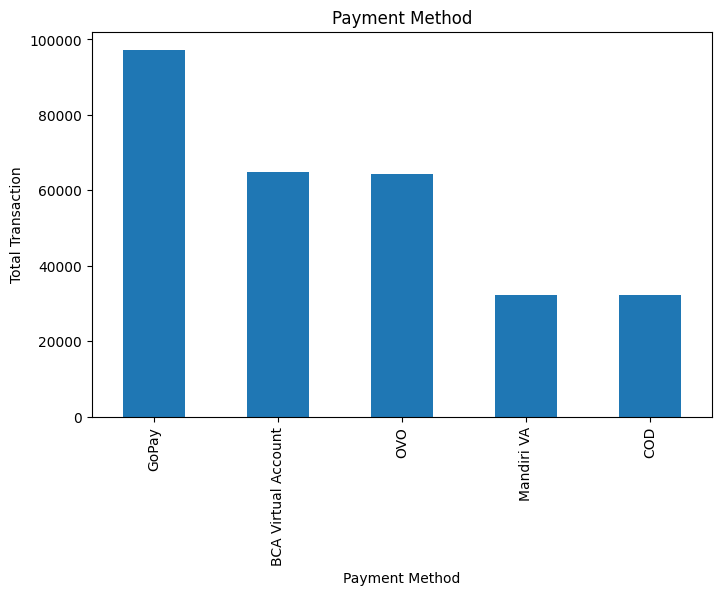

In [56]:
payment = df['payment_method'].value_counts()

plt.figure(figsize=(8,5))
payment.plot(kind='bar')

plt.title('Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Transaction')

plt.show()

### b. Visualisasi Kurir

Visualisasi digunakan untuk mengetahui perusahaan kurir yang paling sering digunakan dalam proses pengiriman pesanan pelanggan.

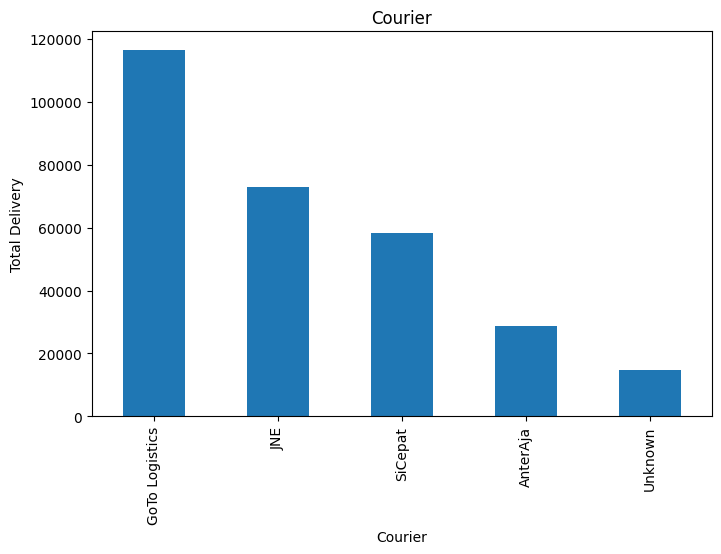

In [57]:
courier = df['courier_name'].value_counts()

plt.figure(figsize=(8,5))
courier.plot(kind='bar')

plt.title('Courier')
plt.xlabel('Courier')
plt.ylabel('Total Delivery')

plt.show()

### c. Visualisasi Lokasi Pelanggan

Visualisasi dilakukan untuk melihat persebaran pelanggan berdasarkan kota sehingga dapat diketahui wilayah dengan jumlah transaksi terbesar.

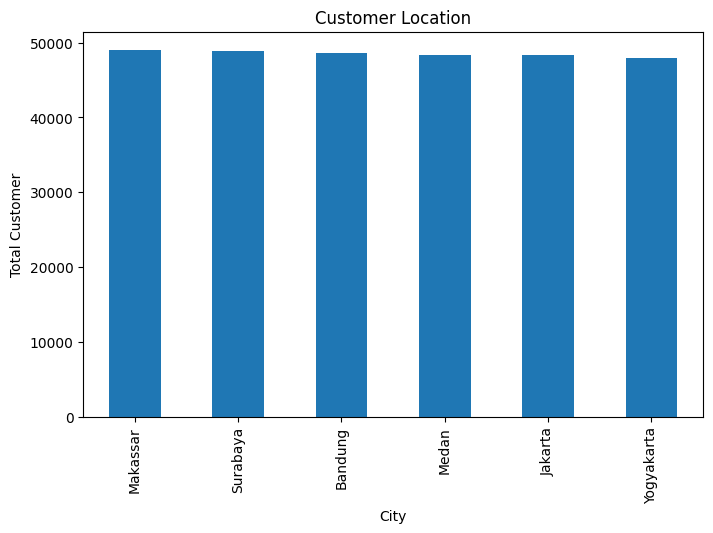

In [58]:
location = df['location'].value_counts()

plt.figure(figsize=(8,5))
location.plot(kind='bar')

plt.title('Customer Location')
plt.xlabel('City')
plt.ylabel('Total Customer')

plt.show()

### d. Visualisasi Usia Pelanggan

Histogram digunakan untuk melihat pola distribusi usia pelanggan yang melakukan transaksi.

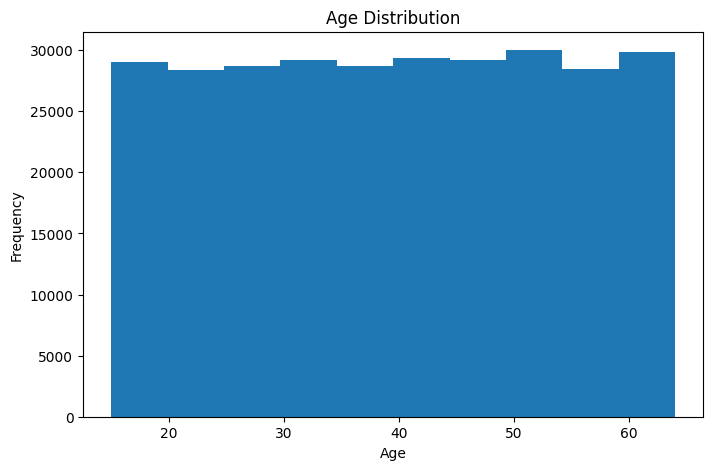

In [59]:
plt.figure(figsize=(8,5))

plt.hist(df['age'], bins=10)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

### e. Visualisasi Durasi Pengiriman

Histogram digunakan untuk menggambarkan distribusi lama waktu pengiriman setelah data yang tidak valid dibersihkan.

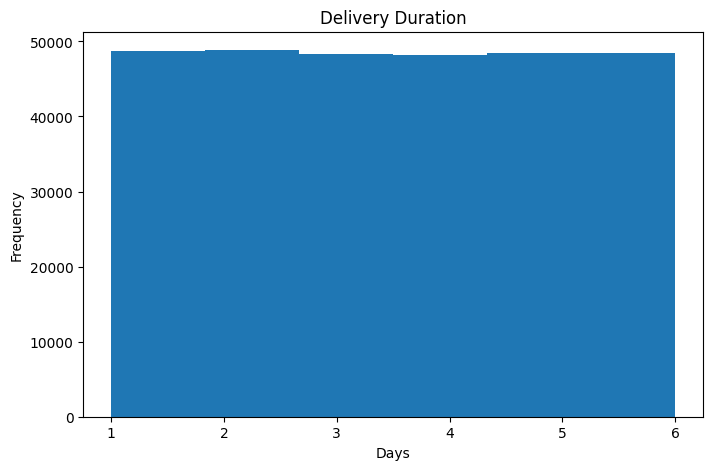

In [60]:
plt.figure(figsize=(8,5))

plt.hist(df['delivery_duration'], bins=6)

plt.title('Delivery Duration')
plt.xlabel('Days')
plt.ylabel('Frequency')

plt.show()

### f. Visualisasi Nilai Transaksi

Boxplot digunakan untuk melihat penyebaran nilai transaksi sekaligus mengidentifikasi keberadaan nilai ekstrem (outlier).

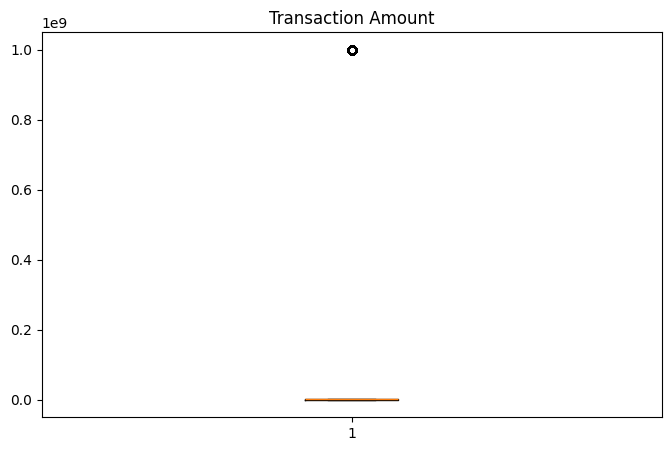

In [61]:
plt.figure(figsize=(8,5))

plt.boxplot(df['total_amount'])

plt.title('Transaction Amount')

plt.show()

### g. Ringkasan Data Visualization

Visualisasi menunjukkan bahwa transaksi didominasi oleh beberapa metode pembayaran dan perusahaan kurir tertentu. Distribusi usia pelanggan relatif tersebar pada rentang usia produktif, sedangkan durasi pengiriman umumnya berada pada beberapa hari setelah barang dikirim. Nilai transaksi menunjukkan variasi yang cukup besar sehingga terdapat sejumlah transaksi bernilai tinggi dibandingkan mayoritas transaksi lainnya.


## **K. Business Insight**


### a. Insight Metode Pembayaran

Hasil analisis menunjukkan bahwa GoPay merupakan metode pembayaran yang paling banyak digunakan pelanggan, diikuti oleh BCA Virtual Account dan OVO. Sementara itu, transaksi menggunakan Mandiri Virtual Account dan COD memiliki jumlah yang lebih sedikit.

Temuan ini menunjukkan bahwa pelanggan cenderung memilih metode pembayaran digital dibandingkan metode pembayaran konvensional. Informasi ini dapat dimanfaatkan perusahaan untuk mempertahankan kerja sama dengan penyedia pembayaran digital serta menyusun strategi promosi yang sesuai dengan preferensi pelanggan.

### b. Insight Kurir

GoTo Logistics menjadi perusahaan kurir dengan jumlah pengiriman terbanyak dibandingkan kurir lainnya. JNE dan SiCepat juga memiliki kontribusi yang cukup besar terhadap total pengiriman, sedangkan AnterAja dan data dengan kategori "Unknown" memiliki jumlah yang relatif lebih rendah.

Hasil ini menunjukkan bahwa sebagian besar proses pengiriman bergantung pada GoTo Logistics sehingga kualitas layanan kurir tersebut perlu terus dipantau agar kepuasan pelanggan tetap terjaga.

### c. Insight Lokasi Pelanggan

Distribusi pelanggan pada enam kota menunjukkan jumlah transaksi yang relatif seimbang. Tidak terdapat kota yang mendominasi secara signifikan sehingga aktivitas transaksi tersebar secara merata.

Kondisi ini mengindikasikan bahwa pasar telah terdistribusi pada beberapa wilayah utama. Oleh karena itu, strategi pemasaran dapat diterapkan secara merata tanpa harus berfokus hanya pada satu lokasi tertentu.

### d. Insight Usia Pelanggan

Pelanggan yang melakukan transaksi berasal dari rentang usia 15 hingga 64 tahun dengan rata-rata usia sekitar 40 tahun. Distribusi usia terlihat cukup merata sehingga aktivitas transaksi tidak didominasi oleh kelompok usia tertentu.

Hal ini menunjukkan bahwa platform mampu menjangkau pelanggan dari berbagai kelompok usia sehingga strategi promosi dapat disesuaikan dengan karakteristik masing-masing segmen pelanggan.

### e. Insight Durasi Pengiriman

Sebagian besar pengiriman berhasil diselesaikan dalam waktu 1 hingga 6 hari. Sebelum proses analisis dilakukan, data dengan durasi pengiriman negatif telah dibersihkan karena tidak sesuai dengan kondisi sebenarnya.

Hasil tersebut menunjukkan bahwa data yang digunakan telah memenuhi kondisi yang lebih baik untuk analisis performa pengiriman. Selanjutnya perusahaan dapat menggunakan indikator durasi pengiriman sebagai salah satu ukuran kualitas layanan logistik.

### f. Insight Nilai Transaksi

Nilai transaksi memiliki variasi yang cukup besar. Sebagian besar transaksi berada pada nilai yang relatif rendah, namun terdapat beberapa transaksi dengan nilai sangat tinggi sehingga menyebabkan penyebaran data menjadi lebar.

Temuan ini menunjukkan bahwa terdapat pelanggan dengan nilai pembelian yang jauh lebih besar dibandingkan mayoritas pelanggan. Kelompok pelanggan tersebut dapat menjadi target program loyalitas maupun promosi khusus untuk meningkatkan retensi pelanggan.

### g. Kesimpulan Business Insight

Berdasarkan hasil proses data cleaning, transformasi data, exploratory data analysis, statistik deskriptif, serta visualisasi data, diperoleh gambaran mengenai karakteristik transaksi pada platform Tokopedia.

Pelanggan lebih banyak menggunakan metode pembayaran digital, dengan GoPay sebagai metode yang paling dominan. Proses pengiriman didominasi oleh GoTo Logistics dengan durasi pengiriman yang umumnya berada pada rentang 1 hingga 6 hari setelah data tidak valid dibersihkan. Distribusi pelanggan pada beberapa kota menunjukkan jumlah transaksi yang relatif merata, demikian pula distribusi usia pelanggan yang tersebar pada berbagai kelompok usia produktif.

Selain itu, analisis nilai transaksi menunjukkan adanya variasi yang cukup besar serta keberadaan transaksi bernilai tinggi yang berpotensi menjadi segmen pelanggan prioritas. Secara keseluruhan, hasil analisis ini dapat digunakan sebagai dasar dalam penyusunan strategi pemasaran, pengembangan layanan logistik, serta peningkatan kualitas pengalaman pelanggan.


## **Conclusion**

Berdasarkan hasil proses data cleaning, transformasi data, exploratory data analysis, statistik deskriptif, serta visualisasi data, diperoleh beberapa temuan utama.

Pelanggan lebih banyak menggunakan metode pembayaran digital dengan GoPay sebagai metode yang paling dominan. Pengiriman didominasi oleh GoTo Logistics dan sebagian besar pesanan berhasil dikirim dalam waktu 1–6 hari. Distribusi pelanggan berdasarkan kota maupun usia relatif merata sehingga tidak terdapat satu segmen yang mendominasi aktivitas transaksi.

Selain itu, nilai transaksi menunjukkan variasi yang cukup besar dengan adanya sejumlah transaksi bernilai tinggi yang berpotensi menjadi pelanggan prioritas. Secara keseluruhan, data menunjukkan bahwa platform memiliki karakteristik pelanggan yang cukup beragam dengan performa pengiriman yang relatif baik.

## **Recommendation**

Berdasarkan hasil analisis, beberapa rekomendasi yang dapat dipertimbangkan antara lain:

1. Mempertahankan dan meningkatkan kerja sama dengan penyedia pembayaran digital karena metode tersebut paling banyak digunakan pelanggan.

2. Melakukan evaluasi performa GoTo Logistics secara berkala mengingat sebagian besar pengiriman menggunakan layanan tersebut.

3. Mengembangkan program loyalitas bagi pelanggan dengan nilai transaksi tinggi untuk meningkatkan retensi pelanggan.

4. Menyusun strategi promosi yang dapat menjangkau berbagai kelompok usia karena distribusi pelanggan relatif merata.

5. Melakukan monitoring kualitas data secara berkala agar nilai yang tidak valid, seperti durasi pengiriman negatif, tidak kembali muncul pada proses analisis berikutnya.

In [62]:
### merged & final CSV file
df.to_csv('tokopedia_final.csv', index=False)

In [63]:
from google.colab import files

files.download('tokopedia_final.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>